# Modeling the Crab Nebula (Synchrotron Self Compton): Example from NAIMA


## Importing packages for the Calculation

In [ ]:
"""
In this block we import the necessary package to perform the non-thermal modeling.
For this, first we need to install the package in the colab terminal
"""
!pip install naima #run only once to install the package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.5 MB/s eta 0:00:00


In [ ]:
# ==================================
# IMPORTING NECESSARY PACKAGES
# ==================================


import astropy.units as u #--PHYSICS UNITS--#
import numpy as np #--NUMERICAL CALCULATION--#
from astropy.constants import c #--LIGHT SPEED--#
from astropy.io import ascii #--TABLE HANDLING--#
from matplotlib import pyplot as plt #--PLOT--#
import naima #--NON-THERMAL MODELING--#
import pandas as pd #--TABLE HANDLING--#
from naima.models import (
    ExponentialCutoffBrokenPowerLaw,
    InverseCompton,
    Synchrotron
)

## **Modeling with NAIMA**

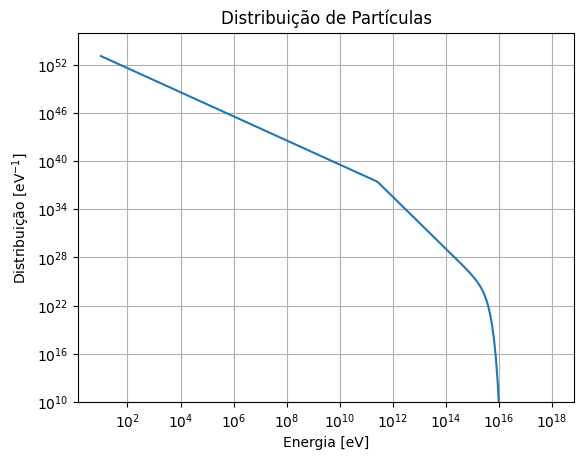

In [ ]:
# ============================
# PARTICLE DISTRIBUTION
# ============================

ECBPL = ExponentialCutoffBrokenPowerLaw(
    amplitude=3.699e36 / u.eV,
    e_0=1 * u.TeV,
    e_break=0.265 * u.TeV,
    alpha_1=1.5,
    alpha_2=3.233,
    e_cutoff=1863 * u.TeV,
    beta=2.0,
)


# ------------------------------------
# PARTICLE DISTRIBUTION VISUALIZATION
# ------------------------------------

def ExpCutBrokPL_plot(energy):
    amplitude=3.699e36 / u.eV
    e_0=1 * u.TeV
    e_break=0.265 * u.TeV
    alpha_1=1.5
    alpha_2=3.233
    e_cutoff=1863 * u.TeV
    beta=2.0

    if energy < e_break:
      return np.exp(- (energiy/e_cutoff)**beta)*amplitude * (energy/e_0)**(-alpha_1)
    else:
      return np.exp(- (energy/e_cutoff)**beta)*amplitude * (e_break/e_0)**(alpha_2-alpha_1)*(energy/e_0)**(-alpha_2)

energy_plot_visual = np.logspace(1,18,250)*u.eV

dist_visual_quantities = []
for energy in energy_plot_visual:
  dist_visual_quantities.append(ExpCutBrokPL_plot(energy))

# Convert list of quantities to a numpy array of values for plotting
dist_visual_values = np.array([q.to(1/u.eV).value for q in dist_visual_quantities])

plt.loglog(energy_plot_visual.to(u.eV).value, dist_visual_values)
plt.xlabel("Energy [eV]")
plt.ylabel("Distribution [eV$^{-1}$]")
plt.title("Particle Distribution")
plt.grid(True, which="both", ls="-")
plt.ylim(1e10,1e56)
plt.show()

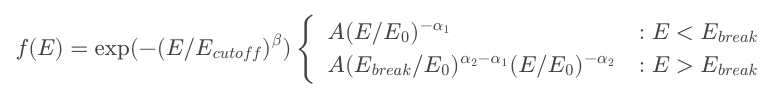

In [ ]:
# ================================
# SYNCHROTRON
# ================================

SYN = Synchrotron(ECBPL, B = 125 * u.uG, Eemax=50 * u.PeV, Eemin=0.1 * u.GeV) #--Synchrotron Function--#

# ---------------------------------
# Photon Spectral Density from the Synchrotron emission assumin R = 2.1 pc
# ---------------------------------

Rpwn = 2.1 * u.pc #--Radius--#

Esy = np.logspace(-7, 9, 100) * u.eV #--Energy array for the synchrotron photons--#

Lsy = SYN.flux(Esy, distance=0 * u.cm)  #--Spectral Luminosity (distance = 0)--#

phn_sy = Lsy / (4 * np.pi * Rpwn**2 * c) * 2.24 #--Spectral density--#



In [ ]:
# ====================================
# INVERSE COMPTON
# ====================================

IC = InverseCompton(
    ECBPL,
    seed_photon_fields=[
        "CMB",
        ["FIR", 70 * u.K, 0.5 * u.eV / u.cm**3],
        ["NIR", 5000 * u.K, 1 * u.eV / u.cm**3],
        ["SSC", Esy, phn_sy],
    ],
    Eemax=50 * u.PeV,
    Eemin=0.1 * u.GeV,
)

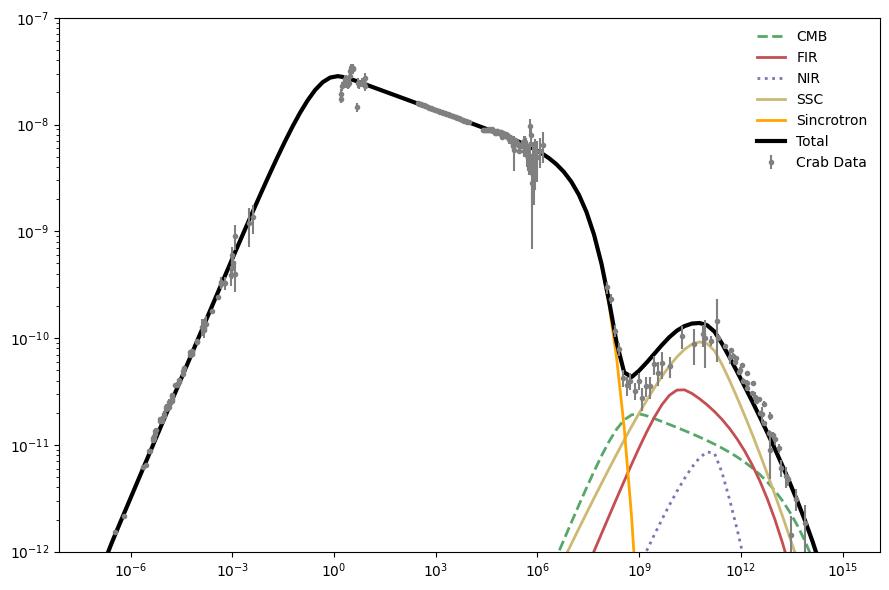

In [ ]:
# ==============================
# DISTANCE
# ==============================

d = 2 * u.kpc

# =================================
# ENERGY ARRAY FOR THE CALCULATION
# =================================

energy = np.logspace(-7, 15, 100) * u.eV

# ===============================
# EMISSION CALCULATION
# ===============================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

# --------------------------------
# inverse compton
# --------------------------------

for i, seed, ls in zip(range(4), ["CMB", "FIR", "NIR", "SSC"], ["--", "-", ":", "-"]):
    ax.loglog(
        energy,
        IC.sed(energy, d, seed=seed),
        lw=2,
        c=naima.plot.color_cycle[i + 1],
        label=seed,
        ls=ls,
    )

# -------------------------------
# synchrotron
# -------------------------------
ax.loglog(
          energy,
          SYN.sed(energy,d),
          lw = 2,
          c = "orange",
          label = "Synchrotron",
          ls = "-",
)



# --------------------------------
# total
# --------------------------------


ax.loglog(
    energy,
    IC.sed(energy, d) + SYN.sed(energy,d),
    lw=3,
    c="k",
    label="Total",
)


# ================================
# PLOT
# ================================

data = ascii.read("CrabNebula_spectrum.ecsv")


ax.errorbar(
    data["energy"].to(u.eV).value,
    data["flux"].to(u.erg * u.cm**-2 * u.s**-1).value,
    yerr=data["flux_error"].to(u.erg * u.cm**-2 * u.s**-1).value,
    marker=".",
    ls="none",
    color="grey",
    label="Crab Data",
)



ax.set_ylim(1e-12, 1e-7)
ax.legend(loc="upper right", frameon=False)
figure.tight_layout()
plt.show()

## **Modeling "Synthetic" Sources**

### Leptonic Source

In [ ]:
# ==========================
# IMPORTING DATA
# ==========================


path_fonte_1 = "fonte_leptonica.csv"

fonte_1_data = pd.read_csv(path_fonte_1)

energy_data = fonte_1_data['energy_eV']

sed_data = fonte_1_data['sed_erg_cm2_s']

sed_err = fonte_1_data['sed_err']

Text(0, 0.5, 'Fluxo [erg cm$^{-2}$ s$^{-1}$]')

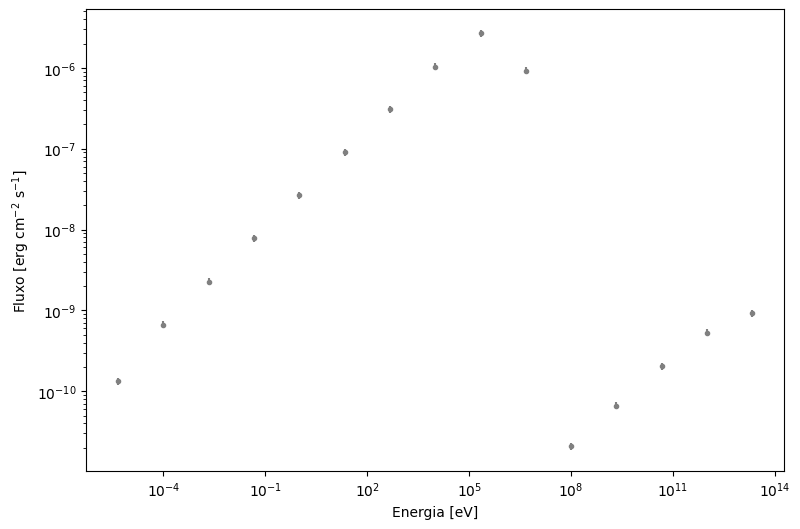

In [ ]:
# ===========================
# VISUALIZING DATA
# ===========================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

ax.errorbar(
    energy_data,# Energy data (energy_data),
    sed_data,# Flux data (sed_data),
    sed_err,# Flux error (sed_err),
    marker=".",
    ls="none",
    color="grey",
)

ax.set_xscale('log')

ax.set_yscale('log')

ax.set_xlabel('Energia [eV]')
ax.set_ylabel('Fluxo [erg cm$^{-2}$ s$^{-1}$]')

In [ ]:
# =============================
# PARTICLE DISTRIBUTION
# =============================

from naima.models import PowerLaw


PL = PowerLaw( amplitude = ?? ,
              e_0 = 1* u.TeV,
               alpha = ?? #
)



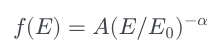

In [ ]:
# =====================
# ENERGY ARRAY
# =====================

E = np.logspace(-6, 14, 200) * u.eV   # 1e-6 eV até 1e14 eV



# ====================
# SYNCHROTRON
# ====================



SYN = Synchrotron(
    particle_distribution = ?? ,
    B = ??
    )


# =====================
# INVERSE COMPTON
# =====================



IC = InverseCompton(
    particle_distribution = ??,
    seed_photon_fields =  [
        "CMB",
        "FIR",
        "NIR"])


In [ ]:

# ===============================
# EMISSION CALCULATION
# ===============================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

d_fonte_1 = 2 *u.kpc

# --------------------------------
# inverse compton
# --------------------------------

for i, seed, ls in zip(range(3), ["CMB", "FIR", "NIR"], ["--", "-", ":"]):
    ax.loglog(
        E,
        IC.sed(E, d_fonte_1, seed=seed),
        lw=2,
        c=naima.plot.color_cycle[i + 1],
        label=seed,
        ls=ls,
    )

# -------------------------------
# synchrotron
# -------------------------------
ax.loglog(
          E,
          SYN.sed(E,d_fonte_1),
          lw = 2,
          c = "orange",
          label = "Synchrotron",
          ls = "-",
)



# --------------------------------
# total
# --------------------------------


ax.loglog(
    E,
   IC.sed(E, d_fonte_1) + SYN.sed(E,d_fonte_1) ,
    lw=3,
    c="k",
    label="Total",
)

# ----------------------------------
# data
# ----------------------------------

ax.errorbar(
    energy_data,# Energy data (energy_data),
    sed_data,# Flux data (sed_data),
    sed_err,# Flux error (sed_err),
    marker=".",
    ls="none",
    color="grey",
)


ax.set_xlabel('$E_{gamma}$ [eV]')
ax.set_ylabel('Flux [erg cm$^{-2}$ s$^{-1}$]')
ax.legend(loc="upper right", frameon=False)



### Mixed Source (Hadrons + Leptons)

In [ ]:
# ==========================
# IMPORTING DATA
# ==========================

path_fonte_2 =  'fonte_mista.csv'

fonte_2_data = pd.read_csv (path_fonte_2)

energy_data_2 = fonte_2_data['energy_eV']

sed_data_2 = fonte_2_data['sed_erg_cm2_s']

sed_err_2 = fonte_2_data['sed_err']


In [ ]:
# ===========================
# DATA VISUALIZATION
# ===========================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

ax.errorbar(
    energy_data_2,# Energy data (energy_data),
    sed_data_2,# Flux data (sed_data),
    sed_err_2,# Flux error (sed_err),
    marker=".",
    ls="none",
    color="grey",
)

ax.set_xscale('log')

ax.set_yscale('log')

In [ ]:
# =============================
# PARTICLE DISTRIBUTION
# =============================



# -------------------
# ELECTRONS
# -------------------

PL = PowerLaw( amplitude = ??,
              e_0 = 1* u.TeV,
               alpha = ??

)

# -------------------
# PROTONS
# -------------------

PL_pp = PowerLaw( amplitude= ??,
    e_0=1 * u.TeV,
    alpha = ?? )

In [ ]:
# =====================
# ENERGY ARRAY
# =====================

E = np.logspace(-6, 14, 200) * u.eV   # 1e-6 eV até 1e14 eV

distance = 2.0 * u.kpc




# ====================
# SYNCHROTRON
# ====================



SYN = Synchrotron(
    PL,#Distribuicao (PL),
    B = ??
    )


# =====================
# INVERSE COMPTON
# =====================



IC = InverseCompton(
    PL,
    seed_photon_fields =  [
        "CMB",
        "FIR",
        "NIR"]
)


# =====================
# PION DECAY
# =====================

from naima.models import PionDecay

PP = PionDecay(
    PL_pp,
    nh = ??
)

In [ ]:

# ===============================
# EMISSION CALCULATION
# ===============================

figure, ax = plt.subplots(1, 1, figsize=(9, 6))

d_fonte_2 = 2 *u.kpc

# --------------------------------
# inverse compton
# --------------------------------

for i, seed, ls in zip(range(3), ["CMB", "FIR", "NIR"], ["--", "-", ":"]):
    ax.loglog(
        E,
        IC.sed(E, d_fonte_2, seed=seed),
        lw=2,
        c=naima.plot.color_cycle[i + 1],
        label=seed,
        ls=ls,
    )

# -------------------------------
# synchrotron
# -------------------------------
ax.loglog(
          E,
          SYN.sed(E,d_fonte_2),
          lw = 2,
          c = "orange",
          label = "Synchrotron",
          ls = "-",
)

# --------------------------------
# PP
# --------------------------------

ax.loglog(
    E,
    PP.sed(E,d_fonte_2),
    c = "red",
    label = "Pion Decay",
    ls = "-"
)

# --------------------------------
# total
# --------------------------------


ax.loglog(
    E,
   IC.sed(E, d_fonte_2) + SYN.sed(E,d_fonte_2) + PP.sed(E,d_fonte_2) ,
    lw=3,
    c="k",
    label="Total",
)

# ----------------------------------
# data
# ----------------------------------

ax.errorbar(
    energy_data_2,# Energy data (energy_data),
    sed_data_2,# Flux data (sed_data),
    sed_err_2,# Flux error (sed_err),
    marker=".",
    ls="none",
    color="grey",
)


ax.set_xlabel('$E_{\gamma}$ [eV]')
ax.set_ylabel('Flux [erg cm$^{-2}$ s$^{-1}$]')
ax.legend(loc="upper right", frameon=False)

plt.ylim(1e-12,1e-5)